In [158]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional

np.set_printoptions(linewidth=200)

In [159]:
epsilon_machine = np.finfo(float).eps

In [160]:
@dataclass
class PlotParams:
    linestyle:  str = "-"
    color:      str = "k"
    linewidth:  int = 1
    marker:     Optional[str] = None
    markersize: int = 1
    markevery:  int = 1
    label:      str = ""

def plot_experiment(ox, oy, params):
    plt.plot(
        ox, oy,
        linestyle   = params.linestyle,
        color       = params.color,
        linewidth   = params.linewidth,
        label       = params.label,
        marker      = params.marker,
        markersize  = params.markersize,
        markevery   = params.markevery
    )

In [161]:
def analytical_derivative_tan(x):
    return 1/(np.cos(x)**2)

def analytical_second_derivative_tan(x):
    return 2*np.sin(x)/(np.cos(x)**3)

def analytical_third_derivative_tan(x):
    return 2*(1+2*np.sin(x)**2)/(np.cos(x)**4)


def right_two_point_derrivative(f, x, h):
    return (f(x + h) - f(x)) / h

def center_two_point_derrivative(f, x, h):
    return (f(x + h) - f(x - h)) / (2 * h)

def left_three_point_derrivative(f, x, h):
    return (3 * f(x) - 4 * f(x - h) + f(x - 2 * h)) / (2 * h)


def right_two_point_derrivative_analytical_error_tan(x, h, epsilon_machine):
    return 0.5 * np.abs(analytical_second_derivative_tan(x)) * h + 2 * np.abs(np.tan(x)) * epsilon_machine / h

def center_two_point_derrivative_analytical_error_tan(x, h, epsilon_machine):
    return np.abs(analytical_third_derivative_tan(x)) * h**2 / 6 + np.abs(np.tan(x)) * epsilon_machine / h

def left_three_point_derrivative_analytical_error_tan(x, h, epsilon_machine):
    return 1 / 3 * np.abs(analytical_third_derivative_tan(x)) * h**2 + 4 * np.abs(np.tan(x)) * epsilon_machine / h

In [162]:
h_arr = np.array([0.25 * 1/(1.01**n) for n in range(0, 10000)])
h_arr = h_arr[h_arr >= 1e-16]

print(h_arr)


[2.50000000e-01 2.47524752e-01 2.45074012e-01 ... 1.02218139e-16 1.01206078e-16 1.00204038e-16]


In [163]:
markevery_i = int(len(h_arr) / 10)
print(markevery_i)

356


In [164]:
plot_args_dict = {
    "right_two_point_derrivative_error":  PlotParams(linestyle = "-", color = "red", linewidth = 3, marker="o", markersize=7, markevery = markevery_i, label = r"Error of $\ \frac{f(x+h)-f(x)}{h}$"),
    "center_two_point_derrivative_error": PlotParams(linestyle = "-", color = "royalblue", linewidth = 3, marker="*", markersize=7, markevery = markevery_i, label = r"Error of $\ \frac{f(x+h)-f(x-h)}{2h}$"),
    "left_three_point_derrivative_error": PlotParams(linestyle = "-", color = "green", linewidth = 3, marker="D", markersize=7, markevery = markevery_i, label = r"Error of $\ \frac{3f(x)-4f(x-h)+f(x-2h)}{2h}$"),
    "right_two_point_derrivative_error_analytical":  PlotParams(linestyle = ":", color = "red", linewidth = 3, marker=None, markersize=5, markevery = markevery_i, label = r"Teoretical error of $\ \frac{f(x+h)-f(x)}{h}$"),
    "center_two_point_derrivative_error_analytical": PlotParams(linestyle = ":", color = "royalblue", linewidth = 3, marker=None, markersize=5, markevery = markevery_i, label = r"Teoretical error of $\ \frac{f(x+h)-f(x-h)}{2h}$"),
    "left_three_point_derrivative_error_analytical": PlotParams(linestyle = ":", color = "green", linewidth = 3, marker=None, markersize=5, markevery = markevery_i, label = r"Teoretical error of $\ \frac{3f(x)-4f(x-h)+f(x-2h)}{2h}$"),
}

In [165]:
data_to_plot_dict = {
    "right_two_point_derrivative_error":  [],
    "center_two_point_derrivative_error": [],
    "left_three_point_derrivative_error": [],
    "right_two_point_derrivative_error_analytical":  [],
    "center_two_point_derrivative_error_analytical": [],
    "left_three_point_derrivative_error_analytical": [],
}

In [166]:
x = 0.5

f = lambda x: np.tan(x)
f_derivative_analytical = lambda x: analytical_derivative_tan(x)

# f = lambda x: np.exp(-1.0 * x ** 2)
# f_derivative_analytical = lambda x: -2.0 * x * np.exp(-1.0 * x **2)


for h in h_arr:
    data_to_plot_dict["right_two_point_derrivative_error"] .append(abs(right_two_point_derrivative(f, x, h)  - f_derivative_analytical(x)))
    data_to_plot_dict["center_two_point_derrivative_error"].append(abs(center_two_point_derrivative(f, x, h) - f_derivative_analytical(x)))
    data_to_plot_dict["left_three_point_derrivative_error"].append(abs(left_three_point_derrivative(f, x, h) - f_derivative_analytical(x)))
    data_to_plot_dict["right_two_point_derrivative_error_analytical"] .append(right_two_point_derrivative_analytical_error_tan(x, h, epsilon_machine))
    data_to_plot_dict["center_two_point_derrivative_error_analytical"].append(center_two_point_derrivative_analytical_error_tan(x, h, epsilon_machine))
    data_to_plot_dict["left_three_point_derrivative_error_analytical"].append(left_three_point_derrivative_analytical_error_tan(x, h, epsilon_machine))



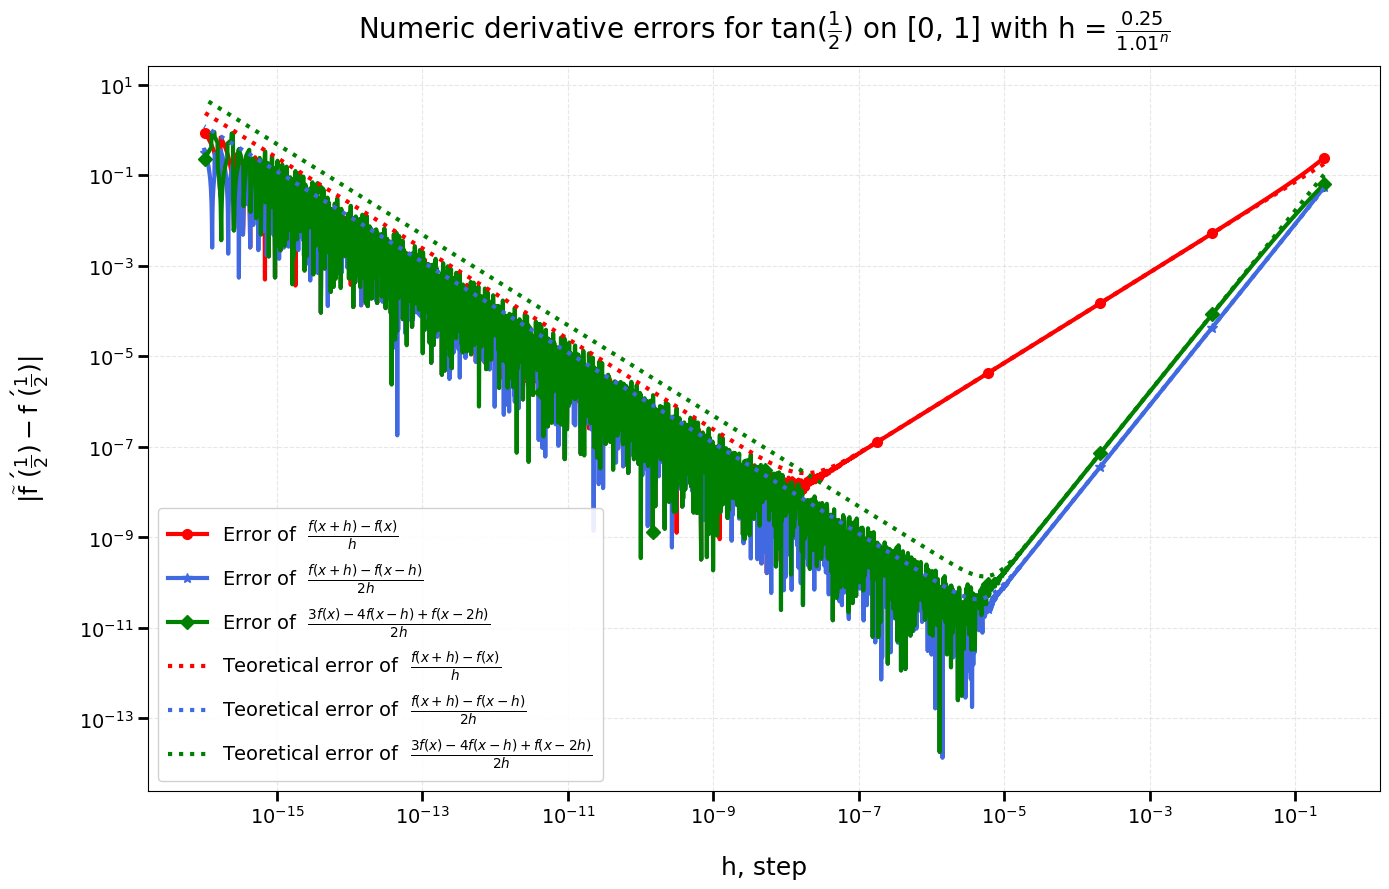

In [167]:
plt.figure(figsize=[14, 9])

# Accumulated
# for key, value in data_to_plot_dict.items():
    
#     min_index = np.argmin(value)
#     left_branch_accumulated = np.maximum.accumulate(value[:min_index + 1][::-1])[::-1]
#     right_branch_accumulated = np.maximum.accumulate(value[min_index + 1:])
#     total_data_to_plot = np.concatenate((left_branch_accumulated, right_branch_accumulated))

#     plot_experiment(h_arr, total_data_to_plot, plot_args_dict[key])

for key, value in data_to_plot_dict.items():
    plot_experiment(h_arr, value, plot_args_dict[key])

plt.title(r'Numeric derivative errors for tan($\frac{1}{2}$) on [0, 1] with h = $\frac{0.25}{1.01^n}$', fontsize=20, pad=20)
plt.xlabel('h, step', fontsize=18, labelpad=20)
plt.ylabel(r'$\mathrm{|\widetilde{f}\ \'(\frac{1}{2}) - f\ \'(\frac{1}{2})|}$', fontsize=18, labelpad=20)
plt.yscale('log')
plt.xscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend(fontsize=14, loc='best', frameon=True, fancybox=True, framealpha=0.9, borderpad=0.5)
plt.tick_params(axis='both', which='major', labelsize=14, length=7, width=2)
plt.tick_params(axis='both', which='minor', labelsize=12, length=4, width=1)
# plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.tight_layout()

plt.show()
plt.close()

In [168]:
data_to_plot_dict["right_two_point_derrivative_error"]

[0.24272946999160316,
 0.23950544394373674,
 0.23633408243907672,
 0.2332142808532638,
 0.230144964131894,
 0.22712508581406476,
 0.2241536270943425,
 0.22122959592141078,
 0.21835202613172444,
 0.21551997661659694,
 0.2127325305212262,
 0.20998879447423757,
 0.20728789784638346,
 0.20462899203714158,
 0.20201124978797513,
 0.19943386452110334,
 0.19689604970268615,
 0.19439703822937804,
 0.19193608183724575,
 0.18951245053211996,
 0.18712543204046095,
 0.18477433127989618,
 0.18245846984860292,
 0.18017718553276163,
 0.17792983183133537,
 0.17571577749747025,
 0.1735344060958386,
 0.17138511557528857,
 0.16926731785617544,
 0.1671804384317972,
 0.1651239159833806,
 0.16309720200805833,
 0.16109976045936203,
 0.15913106739971972,
 0.15719061066449092,
 0.1552778895371152,
 0.1533924144349248,
 0.15153370660523247,
 0.14970129783128594,
 0.14789473014774357,
 0.14611355556528038,
 0.14435733580401777,
 0.14262564203542238,
 0.14091805463237295,
 0.13923416292710522,
 0.1375735649767189,